In [93]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

In [103]:
# Load Data set 

path = "D:/Personal/MSc/MSc. Data Science/Lecture Notes/2. Principles of DS/Assignment and Passpapers/Assignments/Portfolio/Group Work/time series data.csv"
df = pd.read_csv(path)

# Check Point 1 - Veryfy loaded data 
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   t            100 non-null    int64
 1   ProductP1    100 non-null    int64
 2   ProductP2    100 non-null    int64
 3   ProductP3    100 non-null    int64
 4   ProductP4    100 non-null    int64
 5   ProductP5    100 non-null    int64
 6   price        100 non-null    int64
 7   temperature  100 non-null    int64
dtypes: int64(8)
memory usage: 6.4 KB
None
   t  ProductP1  ProductP2  ProductP3  ProductP4  ProductP5  price  \
0  1        197         66        266        113          2      1   
1  2        153         44        264         74          1      2   
2  3        128         55        317        116          0      1   
3  4        133         57        390         70          0      2   
4  5        120         47        440        141          1      1   

   temperature  
0           18  

In [101]:
# Check the "t" value 
print(df["t"].head())  # Check the first few values

0    1
1    2
2    3
3    4
4    5
Name: t, dtype: int64


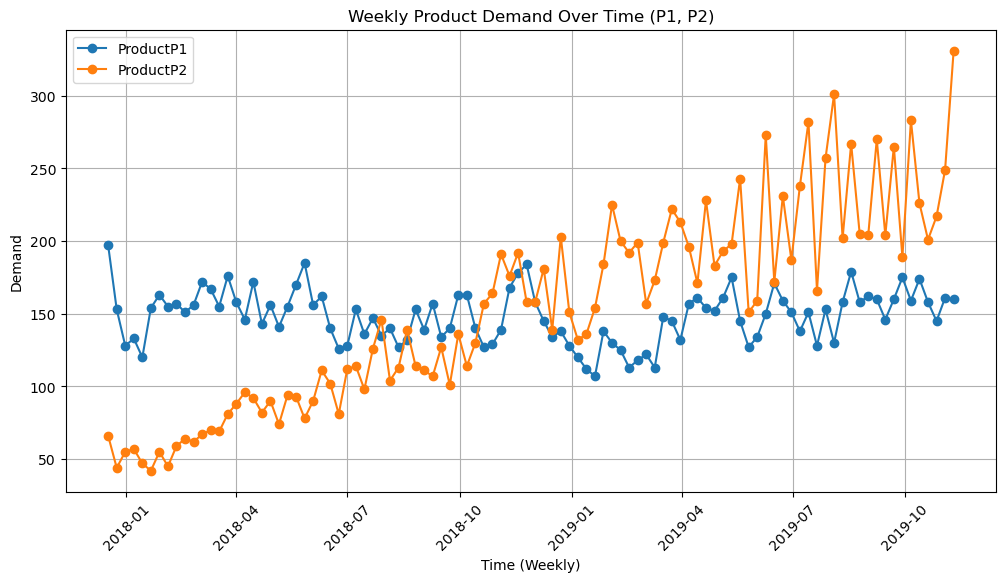

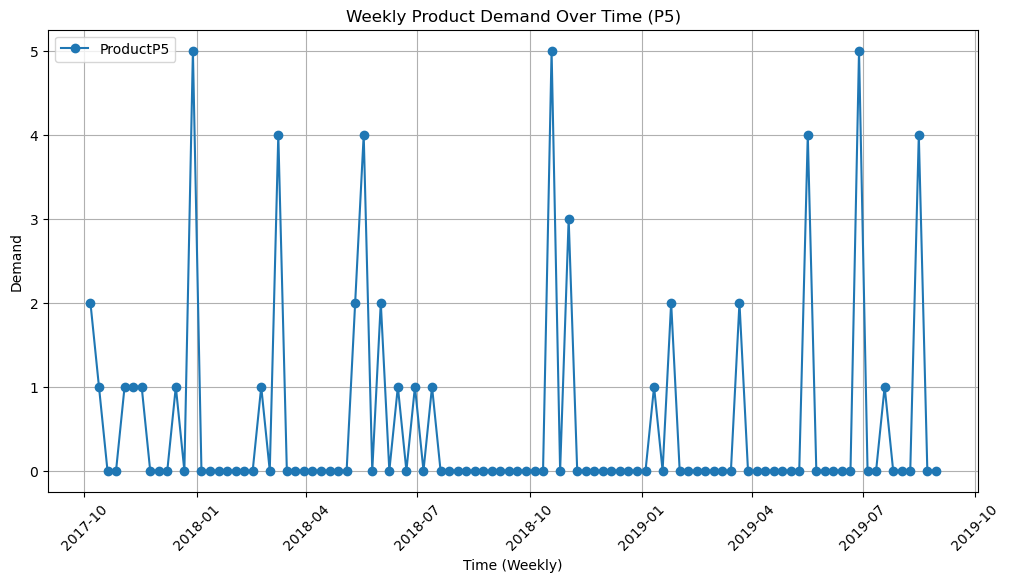

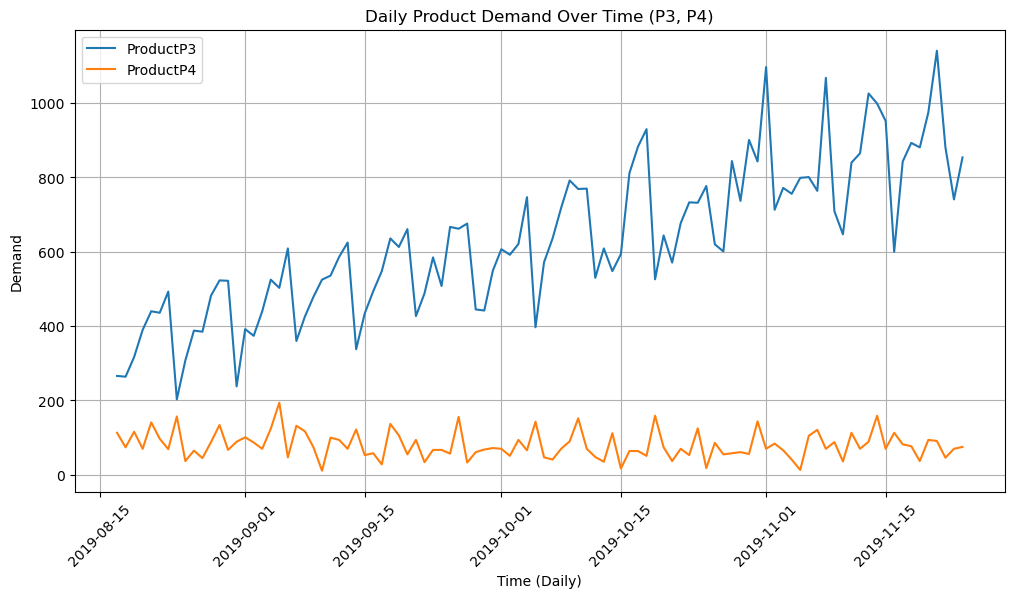

In [105]:
# Plot data in similar time intervals 

# Define the last known dates for each product type
lastdate_p1_p2 = pd.to_datetime("2019-11-10")  # Last date for P1, P2 (weekly)
lastdate_p3_p4 = pd.to_datetime("2019-11-24")  # Last date for P3, P4 (daily)
lastdate_p5 = pd.to_datetime("2019-08-30")  # Last date for P5 (weekly)

# Reverse time calculation based on the number of entries
df["t_daily"] = lastdate_p3_p4 - pd.to_timedelta(df["t"].max() - df["t"], unit="D")  # Daily data (P3, P4)
df["t_weekly_p1_p2"] = lastdate_p1_p2 - pd.to_timedelta((df["t"].max() - df["t"]) * 7, unit="D")  # Weekly data (P1, P2)
df["t_weekly_p5"] = lastdate_p5 - pd.to_timedelta((df["t"].max() - df["t"]) * 7, unit="D")  # Weekly data (P5)

# Plot Weekly Data (P1, P2)
plt.figure(figsize=(12, 6))
for col in ["ProductP1", "ProductP2"]:
    plt.plot(df["t_weekly_p1_p2"], df[col], label=col, marker="o")

plt.xlabel("Time (Weekly)")
plt.ylabel("Demand")
plt.legend()
plt.title("Weekly Product Demand Over Time (P1, P2)")
plt.xticks(rotation=45)
plt.grid()
plt.show()

# Plot Weekly Data (P5)
plt.figure(figsize=(12, 6))
plt.plot(df["t_weekly_p5"], df["ProductP5"], label="ProductP5", marker="o")

plt.xlabel("Time (Weekly)")
plt.ylabel("Demand")
plt.legend()
plt.title("Weekly Product Demand Over Time (P5)")
plt.xticks(rotation=45)
plt.grid()
plt.show()

# Plot Daily Data (P3, P4)
plt.figure(figsize=(12, 6))
for col in ["ProductP3", "ProductP4"]:
    plt.plot(df["t_daily"], df[col], label=col)

plt.xlabel("Time (Daily)")
plt.ylabel("Demand")
plt.legend()
plt.title("Daily Product Demand Over Time (P3, P4)")
plt.xticks(rotation=45)
plt.grid()
plt.show()


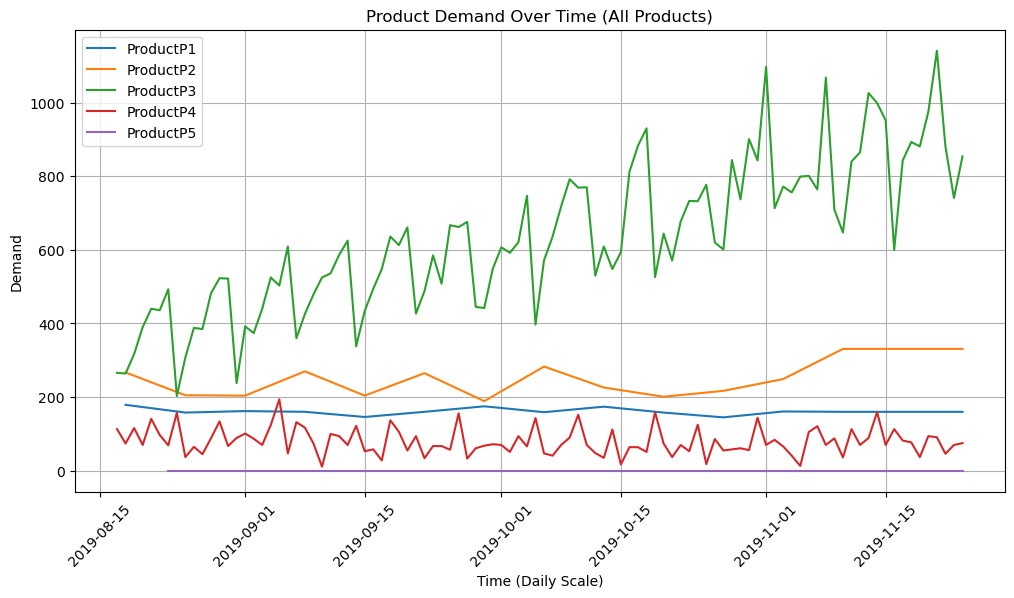

In [111]:
# plot all data in same grapha 

# Interpolate weekly data to match daily scale
df_interpolated = df.set_index("t_daily").reindex(pd.date_range(df["t_daily"].min(), df["t_daily"].max(), freq="D"))
df_interpolated["ProductP1"] = df.set_index("t_weekly_p1_p2")["ProductP1"].reindex(df_interpolated.index).interpolate()
df_interpolated["ProductP2"] = df.set_index("t_weekly_p1_p2")["ProductP2"].reindex(df_interpolated.index).interpolate()
df_interpolated["ProductP5"] = df.set_index("t_weekly_p5")["ProductP5"].reindex(df_interpolated.index).interpolate()
df_interpolated["ProductP3"] = df.set_index("t_daily")["ProductP3"].reindex(df_interpolated.index)
df_interpolated["ProductP4"] = df.set_index("t_daily")["ProductP4"].reindex(df_interpolated.index)

# Plot all products in the same chart
plt.figure(figsize=(12, 6))

for col in ["ProductP1", "ProductP2", "ProductP3", "ProductP4", "ProductP5"]:
    plt.plot(df_interpolated.index, df_interpolated[col], label=col)

plt.xlabel("Time (Daily Scale)")
plt.ylabel("Demand")
plt.legend()
plt.title("Product Demand Over Time (All Products)")
plt.xticks(rotation=45)
plt.grid()
plt.show()


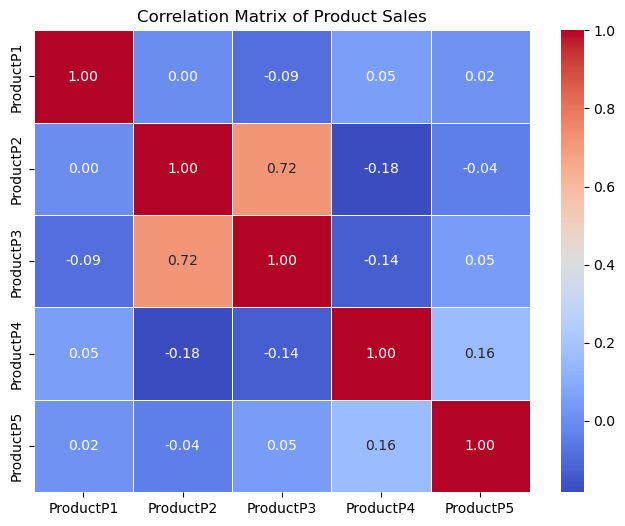

In [115]:
# Compute correlation matrix between the five products
import pandas as pd

# Ensure the dataset is loaded before running this
product_columns = ["ProductP1", "ProductP2", "ProductP3", "ProductP4", "ProductP5"]
correlation_matrix = df[product_columns].corr()

# Display the correlation matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Product Sales")
plt.show()


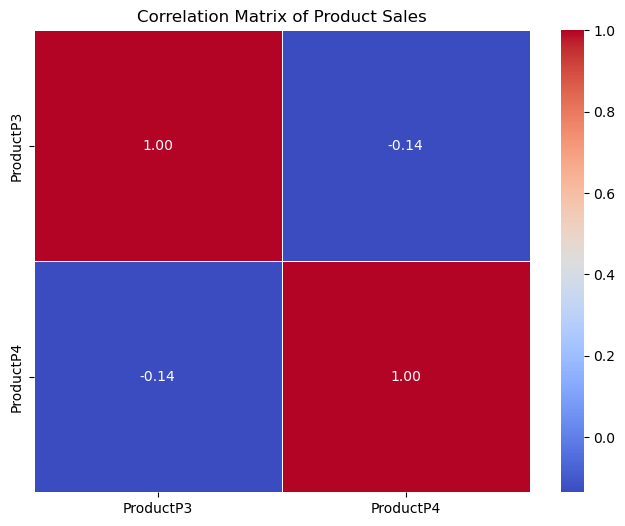

In [117]:
# Compute correlation matrix between the P3 and P4
import pandas as pd

# Ensure the dataset is loaded before running this
product_columns = ["ProductP3", "ProductP4"]
correlation_matrix = df[product_columns].corr()

# Display the correlation matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Product Sales")
plt.show()


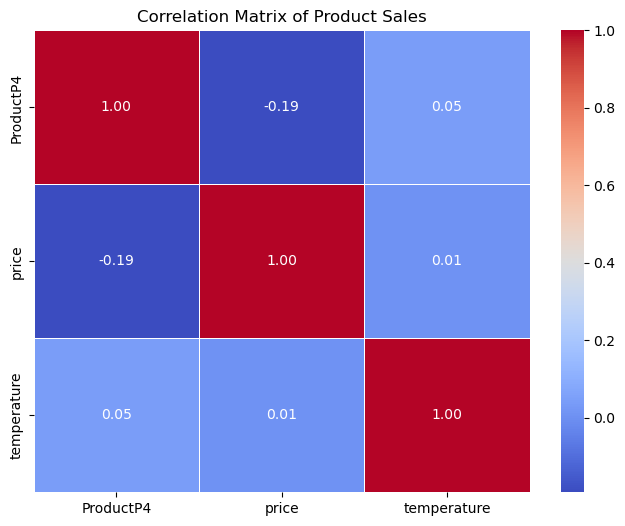

In [121]:
# Compute correlation matrix between the P4 and Price and Temparature 
import pandas as pd

# Ensure the dataset is loaded before running this
product_columns = ["ProductP4", "price", "temperature"]
correlation_matrix = df[product_columns].corr()

# Display the correlation matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Product Sales")
plt.show()
